## Устанавливаем нужные пакеты и потом импортируем их

In [ ]:
!pip install numpy
!pip install matplotlib
!pip install sounddevice
!pip install scipy

In [ ]:
!apt-get update -qq
!apt-get install -y -qq libportaudio2
!pip install -q sounddevice

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libportaudio2:amd64.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../libportaudio2_19.6.0-1.1_amd64.deb ...
Unpacking libportaudio2:amd64 (19.6.0-1.1) ...
Setting up libportaudio2:amd64 (19.6.0-1.1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.11) ...
/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm_debug.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd

## Шумы

*Белый шум* - стационарный шум, спектральные составляющие которого равномерно распределены по всему диапазону задействованных частот.
В нем частоты всего звукового диапазона, который человеческий слух может воспринять: от 20 до 20 000 Гц.
Другими словами, белый шум – это «смесь» звуков, воспроизводимых одновременно на всех частотах, которые воспринимает наше ухо.


*Аддитивный белый гауссовский шум (AWGN)* - базовая модель шума, используемая в теории информации для имитации эффекта многих случайных процессов, происходящих в природе. Модификаторы обозначают специфические характеристики:

**Аддитивный**, потому что он добавляется к любому шуму, который может быть присущ информационной системе.

**Белый шум** относится к идее о том, что он имеет равномерную спектральную плотность мощности во всей полосе частот информационной системы. Это аналогия с белым цветом, который может быть реализован за счет равномерного излучения на всех частотах в видимом спектре.

**Гауссовский**, потому что он имеет нормальное распределение во временной области со средним значением во временной области, равным нулю (гауссовский процесс).



In [ ]:
# глобальные переменные, которые нам нужны для генерации всех шумов. Можно обойтись и без них.

duration = 5  # Продолжительность в секундах
sample_rate = 4100  # Частота дискретизации в Гц

In [ ]:
# счиетаем, сколько элементов будем генерировать.
#Не забываем привести к инту, так как и длительность (duration) и частота (sample_rate) могут быть вещественными

num_samples = int(duration * sample_rate)

In [ ]:
# генерируем просто белый шум, не озадачиваесь его распределением. И печатаем.

white_noise_simple = np.random.random(num_samples)

print(white_noise_simple)

[0.79389909 0.12756139 0.81153134 ... 0.75853083 0.18215833 0.78878879]


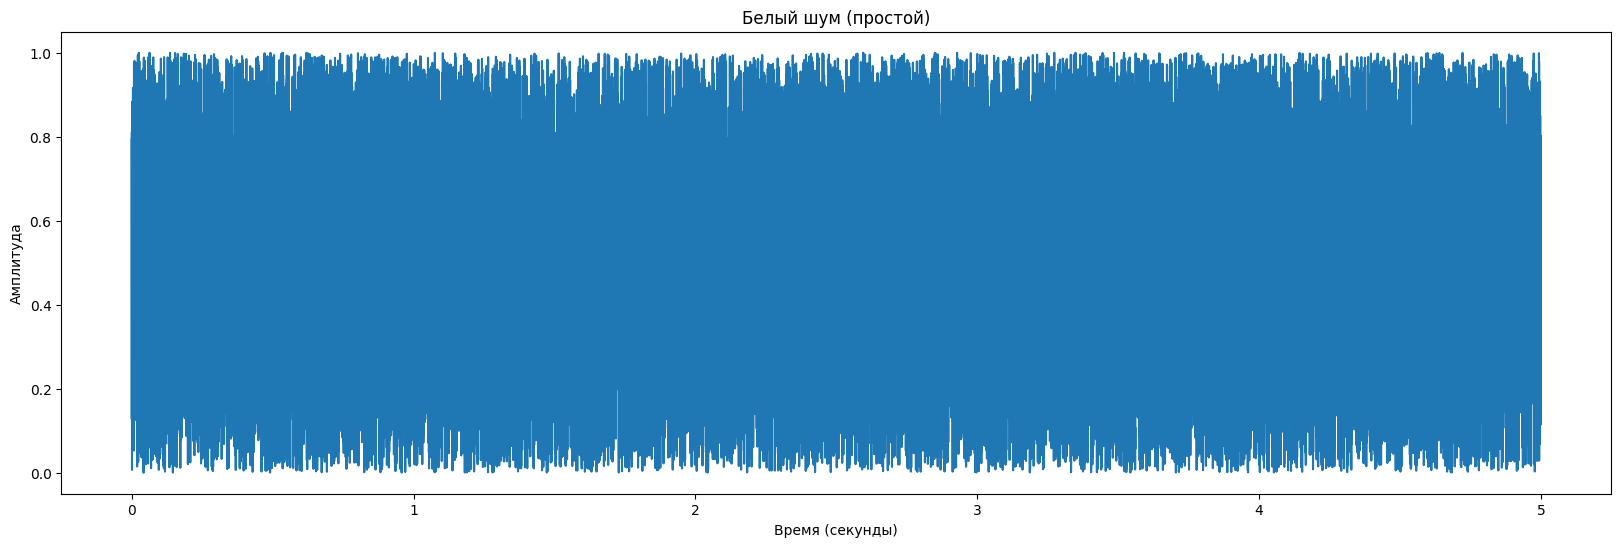

In [ ]:
# отрисовываем, что получилось

# создаем временную шкалу. Считаем, что она начинается с 0, до окончания записи (duretion).
# Между этими значениями равномерно заполняем ряд time_axis, чтобы в нем оказалось ровно столько элементов, сколько во временном ряду
time_axis = np.linspace(0, duration, len(white_noise_simple))

# заданем параметры полотна, на котором будем рисовать
plt.figure(figsize=(20, 6))

# определяем, что будем отрисовывать. По x - time_axis, по y - white_noise_simple
plt.plot(time_axis, white_noise_simple)

# заголовки
plt.title('Белый шум (простой)')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')

# команда на отрисовку
plt.show()


In [ ]:
import sounddevice as sd
print(sd.query_devices())

In [ ]:
from IPython.display import Audio, display
import numpy as np

audio_data = white_noise_simple * 2 - 1
display(Audio(audio_data, rate=sample_rate))

In [ ]:
# генерируем гауссовский белый шум
# loc - медиана
# scale - стандартная девиация

white_noise_g = np.random.normal(loc = 0, scale = 1, size = num_samples)

print(white_noise_g)

[ 1.68729607 -0.62957643 -0.50122654 ... -0.87683638 -0.25564572
  0.92674497]


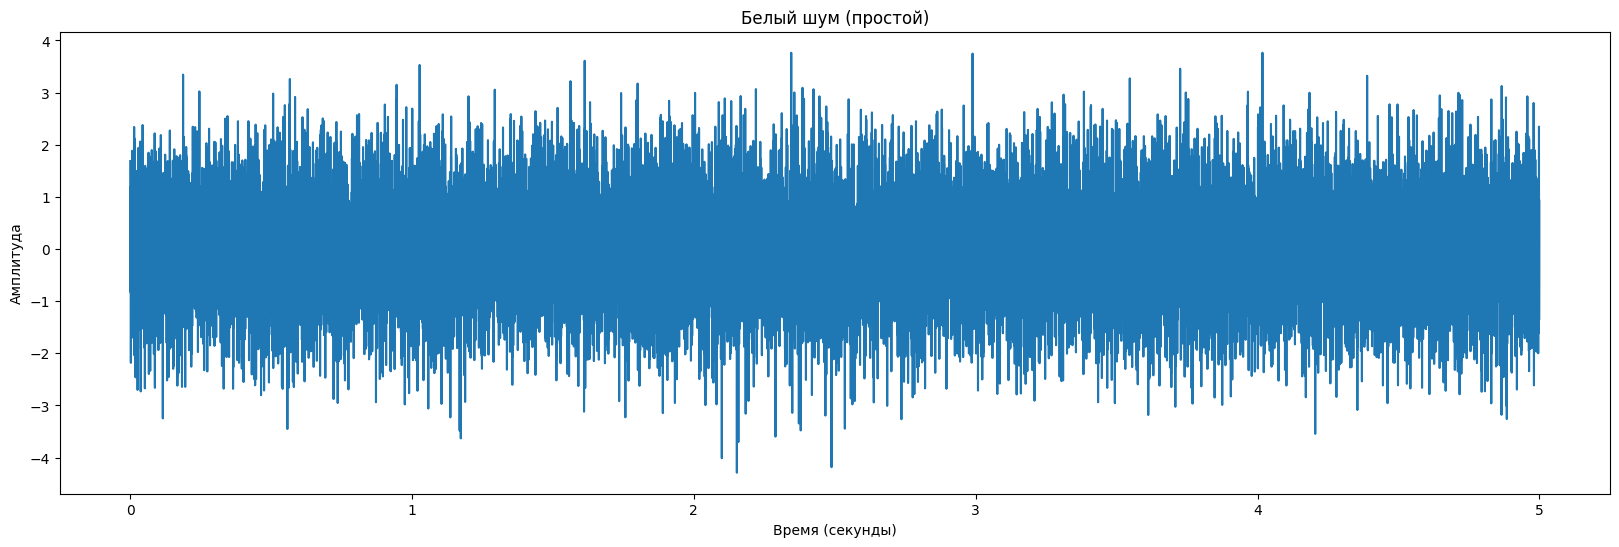

In [ ]:
# отрисовываем, что получилось

# создаем временную шкалу. Считаем, что она начинается с 0, до окончания записи (duretion).
# Между этими значениями равномерно заполняем ряд time_axis, чтобы в нем оказалось ровно столько элементов, сколько во временном ряду
time_axis = np.linspace(0, duration, len(white_noise_g))

# заданем параметры полотна, на котором будем рисовать
plt.figure(figsize=(20, 6))

# определяем, что будем отрисовывать. По x - time_axis, по y - white_noise_simple
plt.plot(time_axis, white_noise_g)

# заголовки
plt.title('Белый шум (простой)')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')

# команда на отрисовку
plt.show()


In [ ]:
audio_signal = white_noise_g / np.max(np.abs(white_noise_g))

display(Audio(audio_signal, rate=sample_rate))

/tmp/ipykernel_665/2795709816.py:25: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([c0, c1],


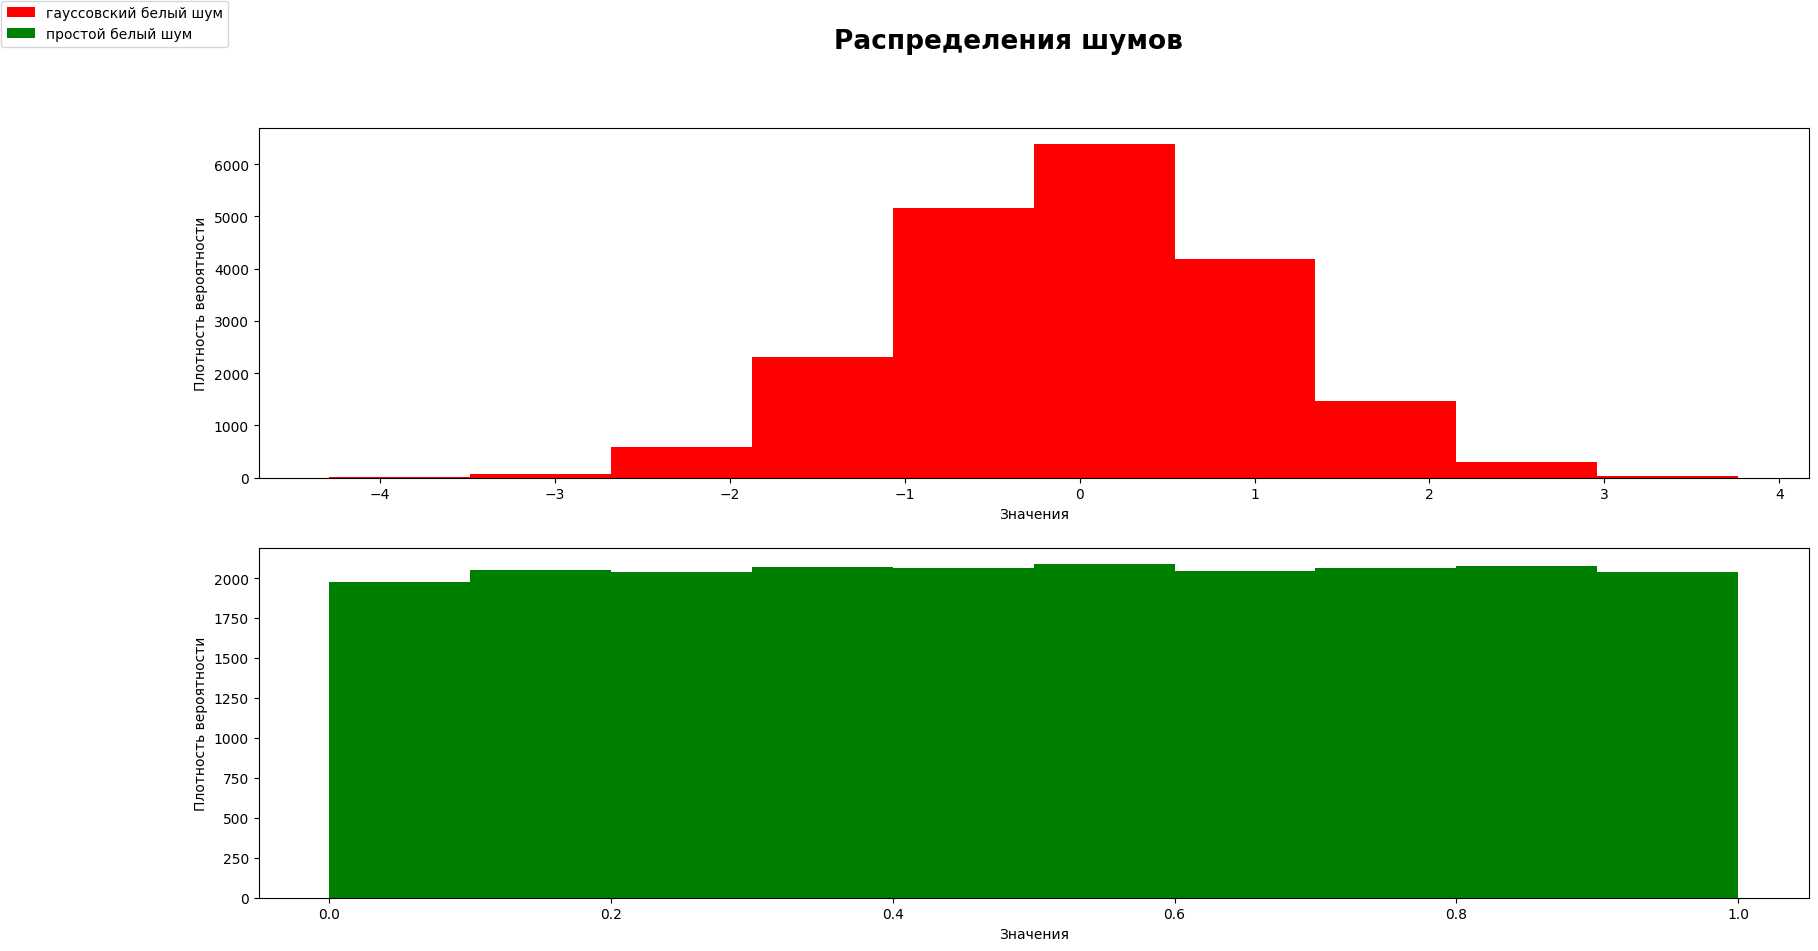

In [ ]:
# давайте сравним распеределения двух шумов. Это можно сделать с помощью функции hist



# хотим нарисовать все на одном рисунке. Нам нужно 2 рисунка, один под другим.
fig, axs = plt.subplots(2, 1, figsize=(20, 10))


# общий заголовок для всей картинки
fig.suptitle('Распределения шумов', fontsize=19, fontweight='bold')

labels = ["гауссовский белый шум", "простой белый шум"]

# определяем, что будем отрисовывать на 1 графике. По x - амплитуды, по y - плотность вероятности
c0 = axs[0].hist(white_noise_g, color="red")
axs[0].set_xlabel('Значения')
axs[0].set_ylabel('Плотность вероятности')

# определяем, что будем отрисовывать. По x - амплитуды, по y - плотность вероятности
c1 = axs[1].hist(white_noise_simple, color ="green")
axs[1].set_xlabel('Значения')
axs[1].set_ylabel('Плотность вероятности')

# отрисовываем общую легенду
fig.legend([c0, c1],
           labels=labels,
           loc='upper left',
           borderaxespad=0.1)

plt.show()


*Коричневый шум* - больше выделяются низкие частоты (имеют высокие амплитуды). Получается интегрирвание белого шума.

Для этого нужно:
Создать белый гауссовкий шум с нулевой медианой.
Вычислить кумулятивную сумму полученного белого шума
От кумулятивной суммы отнять медианное значение
Отмасштабировать

На заметку:
Коричневый шум имеет ОГРОМНОЕ количество энергии на очень низких частотах и теоретически бесконечную энергию на частоте 0 Гц. Это, скорее всего, перегрузит любую разумную систему, поэтому вам, вероятно, понадобится коричневый шум с «ограниченной полосой пропускания». Самый простой способ сделать это — использовать фильтр верхних и нижних частот первого порядка вместо интегратора. Например, фильтр верхних частот на частоте 20 Гц и фильтр нижних частот на частоте 40 Гц.


In [ ]:
# белый шум у нас уже есть. Давайте просто работать с ним
# Создайте коричневый шум
# ВАШ КОД


brown_noise = np.cumsum(white_noise_g)
brown_noise = brown_noise - np.median(brown_noise)
#это чтобы у нас все от -1 до 1 было
if np.max(np.abs(brown_noise)) > 0:
    brown_noise = brown_noise / np.max(np.abs(brown_noise))

print(brown_noise)
print(white_noise_g)

[ 0.25412422  0.24949372  0.24580723 ... -0.43570153 -0.43758179
 -0.43076563]
[ 1.68729607 -0.62957643 -0.50122654 ... -0.87683638 -0.25564572
  0.92674497]


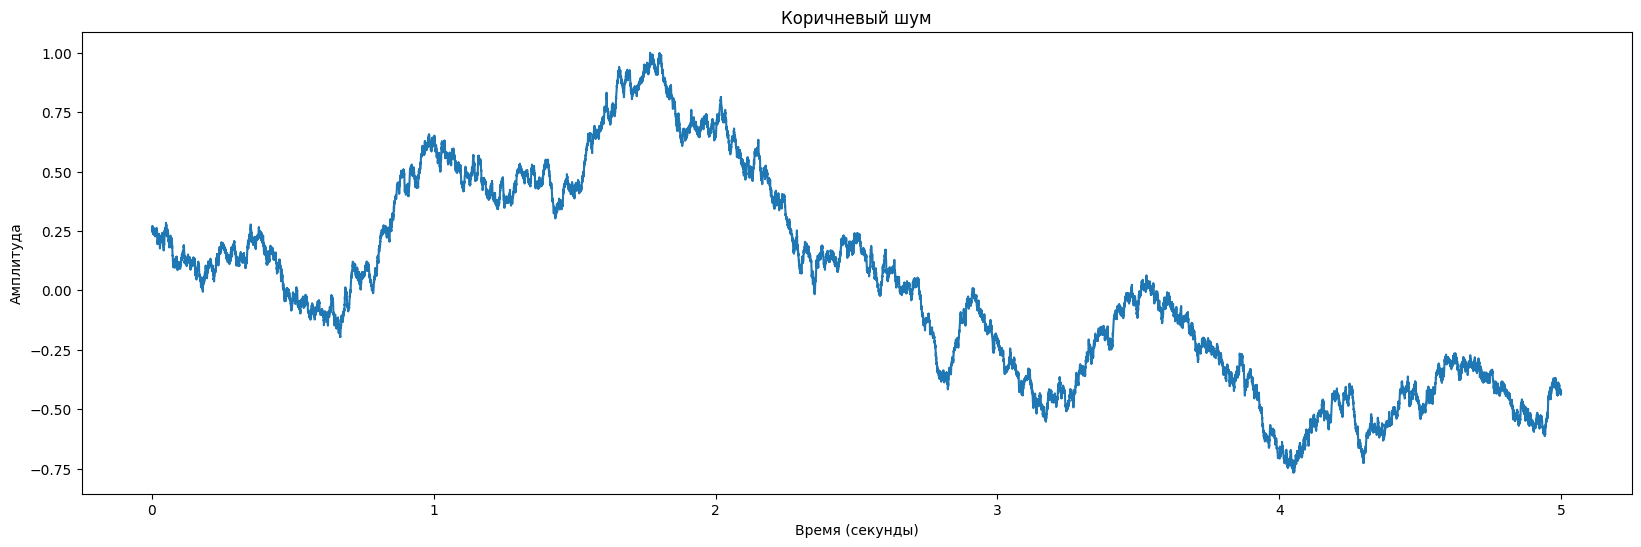

In [ ]:
# отрисовываем, что получилось
# создаем временную шкалу. Считаем, что она начинается с 0, до окончания записи (duretion).
# Между этими значениями равномерно заполняем ряд time_axis, чтобы в нем оказалось ровно столько элементов, сколько во временном ряду
time_axis = np.linspace(0, duration, len(brown_noise))

# заданем параметры полотна, на котором будем рисовать
plt.figure(figsize=(20, 6))

# определяем, что будем отрисовывать. По x - time_axis, по y - white_noise_simple
plt.plot(time_axis, brown_noise)

# заголовки
plt.title('Коричневый шум')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')

# команда на отрисовку
plt.show()



In [ ]:
display(Audio(brown_noise, rate=sample_rate))

*Розовый шум* или фликкер (мерцающий) шум - очень похож на белый.

Розовый шум может быть сгенерирован путем первой генерации сигнала белого шума, преобразования его Фурье, затем деления амплитуд различных частотных составляющих на квадратный корень из частоты (в одном измерении) или на частоту (в двух измерениях) и т.д. Это эквивалентно пространственной фильтрации (свертке) сигнала белого шума с помощью фильтра от белого к розовому. Для сигнала длины N в одном измерении фильтр имеет следующий вид:

![Alt text](image-1.png)

In [ ]:
# применение фильтра для генерации розового шума

N = len(white_noise_g)
N2 = N//2

print(N)
print(N2)

pink_noise_f = []

for el in white_noise_g:

    s = 0
    for k in range(1,N2):
        s += 1/np.sqrt(k) * np.cos(2*np.pi*k*(el-1)/N)
    s *=2
    s = s + 1 + np.cos(np.pi*(el-1))/np.sqrt(N2)

    pink_noise_f.append(s/N)
    print(len(pink_noise_f))


Выходные данные были обрезаны до нескольких последних строк (5000).
8886
8887
8888
8889
8890
8891
8892
8893
8894
8895
8896
8897
8898
8899
8900
8901
8902
8903
8904
8905
8906
8907
8908
8909
8910
8911
8912
8913
8914
8915
8916
8917
8918
8919
8920
8921
8922
8923
8924
8925
8926
8927
8928
8929
8930
8931
8932
8933
8934
8935
8936
8937
8938
8939
8940
8941
8942
8943
8944
8945
8946
8947
8948
8949
8950
8951
8952
8953
8954
8955
8956
8957
8958
8959
8960
8961
8962
8963
8964
8965
8966
8967
8968
8969
8970
8971
8972
8973
8974
8975
8976
8977
8978
8979
8980
8981
8982
8983
8984
8985
8986
8987
8988
8989
8990
8991
8992
8993
8994
8995
8996
8997
8998
8999
9000
9001
9002
9003
9004
9005
9006
9007
9008
9009
9010
9011
9012
9013
9014
9015
9016
9017
9018
9019
9020
9021
9022
9023
9024
9025
9026
9027
9028
9029
9030
9031
9032
9033
9034
9035
9036
9037
9038
9039
9040
9041
9042
9043
9044
9045
9046
9047
9048
9049
9050
9051
9052
9053
9054
9055
9056
9057
9058
9059
9060
9061
9062
9063
9064
9065
9066
9067
9068
9069
9070
9071
90

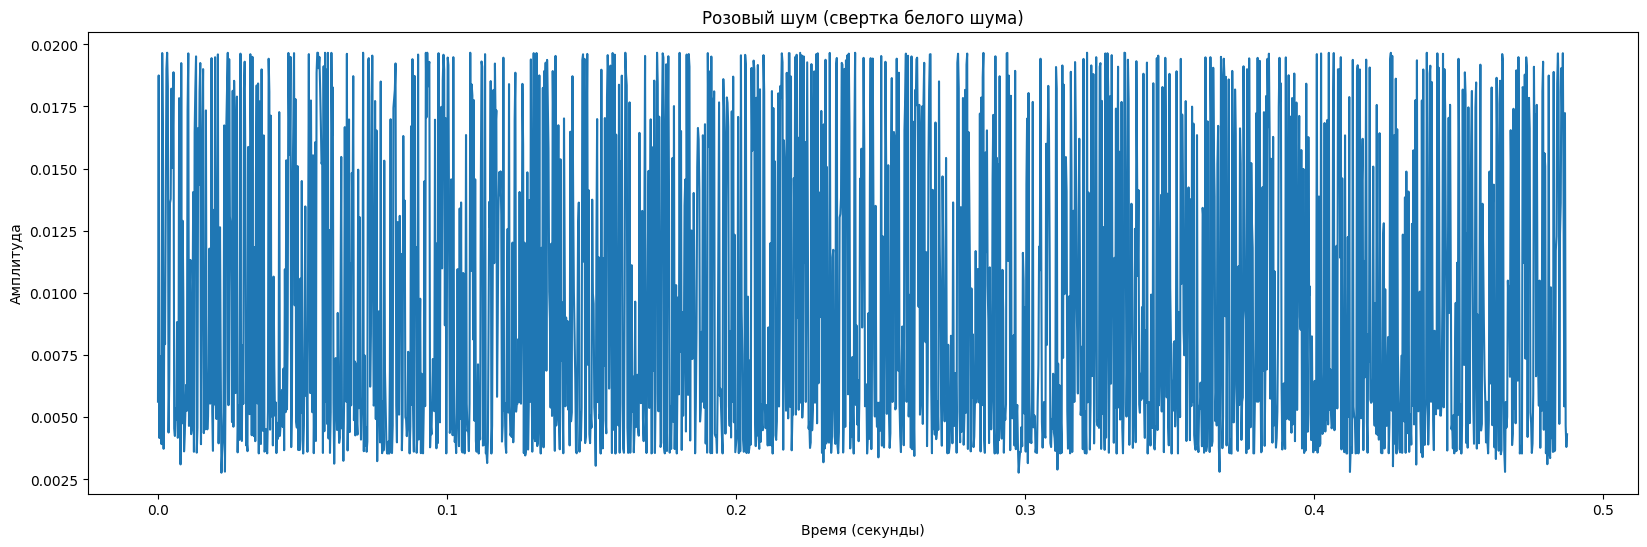

In [ ]:
# отрисовываем, что получилось
# создаем временную шкалу. Считаем, что она начинается с 0, до окончания записи (duretion).
# Между этими значениями равномерно заполняем ряд time_axis, чтобы в нем оказалось ровно столько элементов, сколько во временном ряду
time_axis = np.linspace(0, duration, len(pink_noise_f))

# заданем параметры полотна, на котором будем рисовать
plt.figure(figsize=(20, 6))

# определяем, что будем отрисовывать. По x - time_axis, по y - white_noise_simple
plt.plot(time_axis[:2000], pink_noise_f[:2000])

# заголовки
plt.title('Розовый шум (свертка белого шума)')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')

# команда на отрисовку
plt.show()

Задание. Сгенерите розовый шум путем первой генерации сигнала белого шума, преобразования его Фурье, затем деления амплитуд различных частотных составляющих на квадратный корень из частоты.

Вам понадобятся функции np.fft.rfft , np.real , np.sqrt

In [ ]:
# ВАШ КОД
# генерим белый шум
white_noise = np.random.normal(loc=0, scale=1, size=num_samples)

fft_white = np.fft.rfft(white_noise)
freq_indices = np.arange(len(fft_white))

filter_coeff = np.ones_like(freq_indices, dtype=float)
filter_coeff[1:] = 1.0 / np.sqrt(freq_indices[1:])
pink_fft = fft_white * filter_coeff
pink_noise = np.fft.irfft(pink_fft, n=num_samples)

pink_noise = pink_noise - np.mean(pink_noise)
max_val = np.max(np.abs(pink_noise))
if max_val > 0:
    pink_noise = pink_noise / max_val

print(pink_noise)

# генерим розовый щум

pink_noise

print(pink_noise)


[-1.28498074e-04 -1.02588949e-01  2.07086479e-02 ... -4.01542714e-01
 -2.19337323e-01 -1.13290759e-01]
[-1.28498074e-04 -1.02588949e-01  2.07086479e-02 ... -4.01542714e-01
 -2.19337323e-01 -1.13290759e-01]


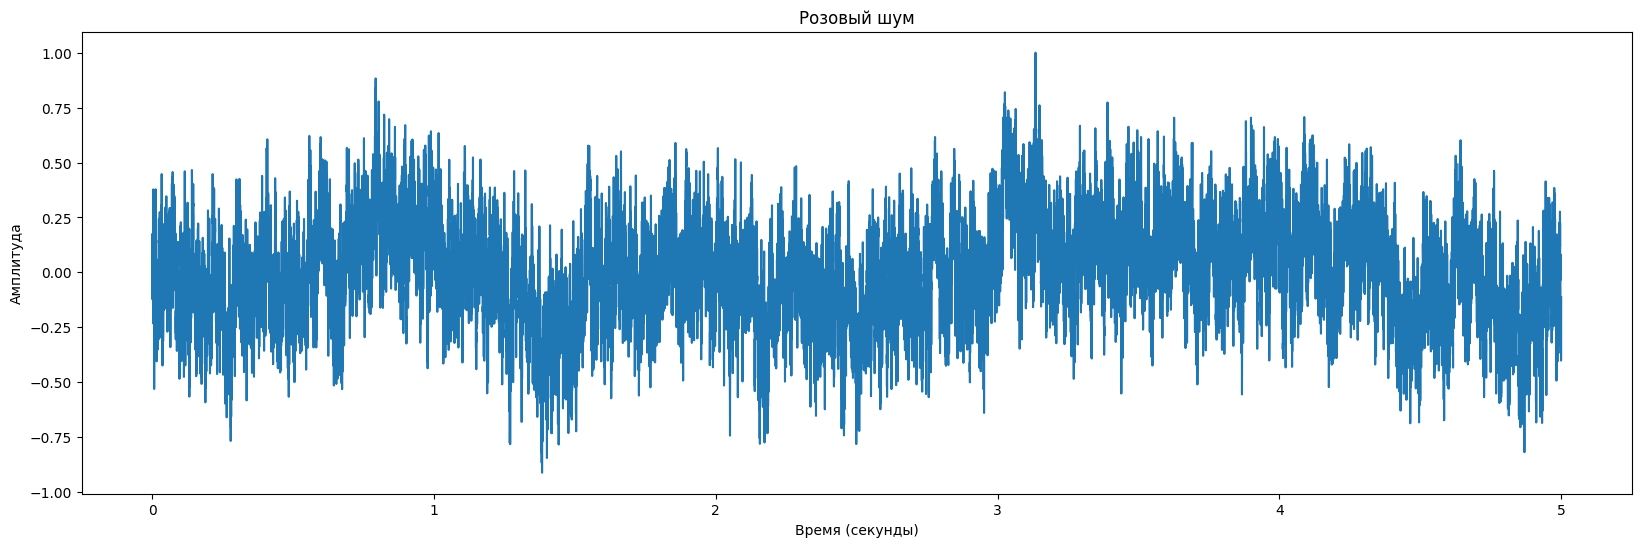

In [ ]:
# отрисовываем, что получилось
# создаем временную шкалу. Считаем, что она начинается с 0, до окончания записи (duretion).
# Между этими значениями равномерно заполняем ряд time_axis, чтобы в нем оказалось ровно столько элементов, сколько во временном ряду
time_axis = np.linspace(0, duration, len(pink_noise))

# заданем параметры полотна, на котором будем рисовать
plt.figure(figsize=(20, 6))

# определяем, что будем отрисовывать. По x - time_axis, по y - white_noise_simple
plt.plot(time_axis, pink_noise)

# заголовки
plt.title('Розовый шум')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')

# команда на отрисовку
plt.show()

In [ ]:
display(Audio(pink_noise, rate=sample_rate, autoplay=False))

*Черный шум*
Или тишина. Или шум на частотах, которые мы не слышим.

In [ ]:
# количество элементов в записи сигнала
num_samples = int(duration * sample_rate)
freq1 = 20000
freq2 = 25000

# Частоты, на которых будем генерировать
num_frequencies = 100  # Количество случайных частот
frequencies = np.linspace(freq1, freq2, num_frequencies) # лист с частотами

black_noise = np.zeros(num_samples)   # подготовили лист для записи сигнала
time_axis = np.arange(num_samples) / sample_rate   # задали временную ось

amplitudes = np.random.normal(0, 1, num_frequencies)  # опять сгенерировали белый гауссовский шум

black_noise = np.zeros(num_samples)
time_axis = np.arange(num_samples) / sample_rate

for i in range(num_frequencies):
        # надо описать, откуда вы взяли эту формулу
        black_noise += amplitudes[i] * np.sin(2 * np.pi * frequencies[i] * time_axis)

#black_noise /= np.max(np.abs(black_noise))  # Нормализация амплитуды к [-1, 1]


# Визуализация
time_axis = np.linspace(0, duration, len(amplitudes))
plt.figure(figsize=(20, 6))
plt.plot(time_axis, amplitudes)
plt.title('Черный шум')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')
plt.show()


In [ ]:
sd.play(amplitudes, freq1)
sd.wait()

Черный шум - как излучение абсолютно черного тела

Cпектральная плотность мощности излучения известна (непрерывную функцию частоты - f и температуры - T):

![Alt text](image.png)

kB - постоянная Больцмана
h  - Постоянная Планка
c  - скорость света

Поскольку выходная величина должна быть выражена в децибелах, чтобы иметь смысл для звука, мы просто используем логарифмическую шкалу и добавляем смещение (усиление), чтобы нормализовать пик до 0. Уравнение кривой эквалайзера равно:

![Alt text](image-2.png)

Еквалайзер применяем к белому шуму

In [ ]:
import scipy

kb =  scipy.constants.k
h = scipy.constants.physical_constants['Planck constant'][0]
c = scipy.constants.c

print(kb)
print(h)
print(c)

T = 17*1/np.power(10, 9)  #Температура 17 нанокельвинов
G = 10

coef1 = 2*h/(c*c*T*T*T)
coef2 = h/(kb*T)

freq1 = 1000

# количество элементов в записи сигнала. Для 17 нанокельвинов полоса пропускания шума будет от 1Гц до 12 кГц
num_samples = int(duration * freq1)


# Частоты, на которых будем генерировать

black_noise = np.zeros(num_samples)   # подготовили лист для записи сигнала
time_axis = np.arange(num_samples) / sample_rate   # задали временную ось



black_noise = np.zeros(num_samples)
time_axis = np.arange(num_samples) / sample_rate
eq = 10 * np.log(coef1*np.power(freq1,3)/(np.exp(coef2*freq1)-1)) + 10 # эквалайзер

white_noise_g = np.random.normal(loc = 0, scale = 1, size = num_samples) # опять белый шум

black_noise = white_noise_g + eq # применяем преобразование к белому шуму

black_noise /= np.max(np.abs(black_noise))  # Нормализация амплитуды к [-1, 1]



1.380649e-23
6.62607015e-34
299792458.0


In [ ]:
# так звучит черное тело

sd.play(black_noise, freq1)
sd.wait()

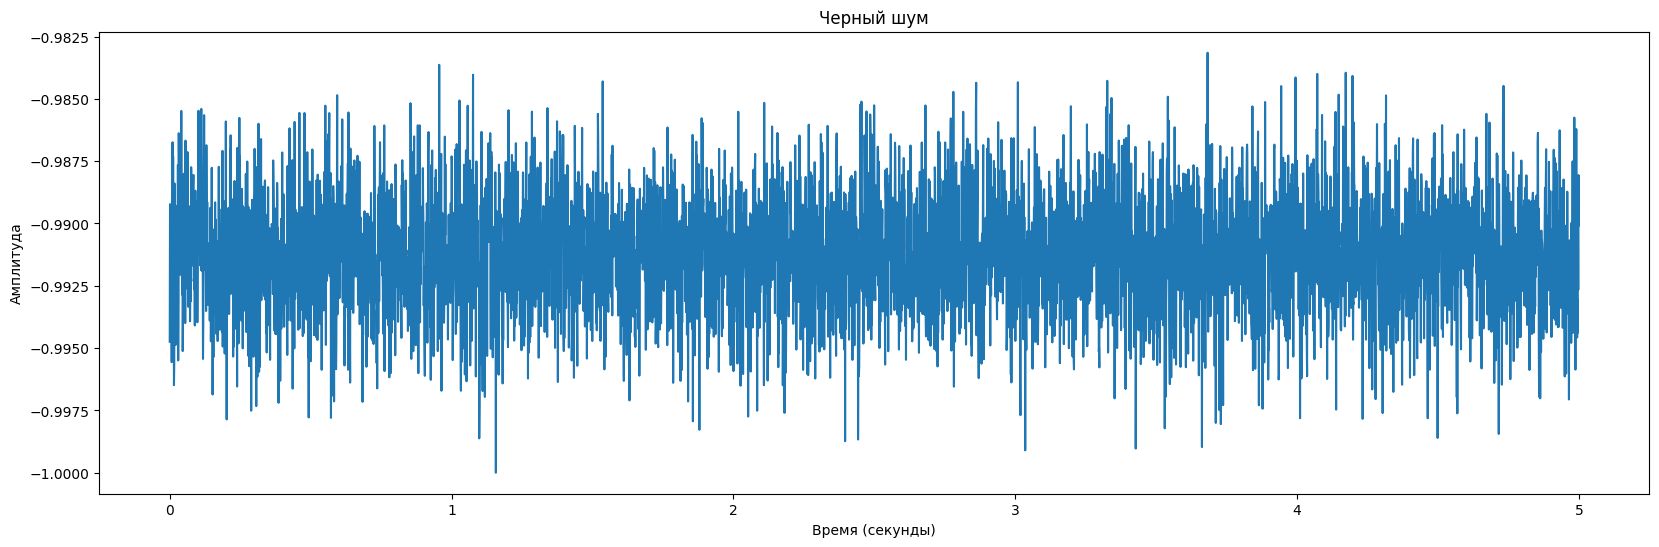

In [ ]:
# Визуализация
time_axis = np.linspace(0, duration, len(black_noise))
plt.figure(figsize=(20, 6))
plt.plot(time_axis, black_noise)
plt.title('Черный шум')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')
plt.show()

## Генерация временных рядов

Этот код создает пример временного ряда, представленного как синусоида с добавлением случайного шума. Это просто пример, можно изменить генерацию данных в соответствии с вашими потребностями.

In [ ]:
duration = 5  # Продолжительность в секундах
sample_rate = 4100  # Частота дискретизации в Гц

num_points = duration*sample_rate  # количество точек

time_points = np.linspace(0, duration, num_points)  # Создаем равномерные временные точки от 0 до 5 секунд

white_noise_base = np.random.normal(0,1,size=num_points)  # Генерим белый шум

values = 10*np.sin(4*time_points*np.pi) # вычисляем амплитуды сигнала по синусоидальному закону

values_noise = values + white_noise_base # зашумляем сигнал



/tmp/ipykernel_665/3043892488.py:27: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([c0, c1, c2],


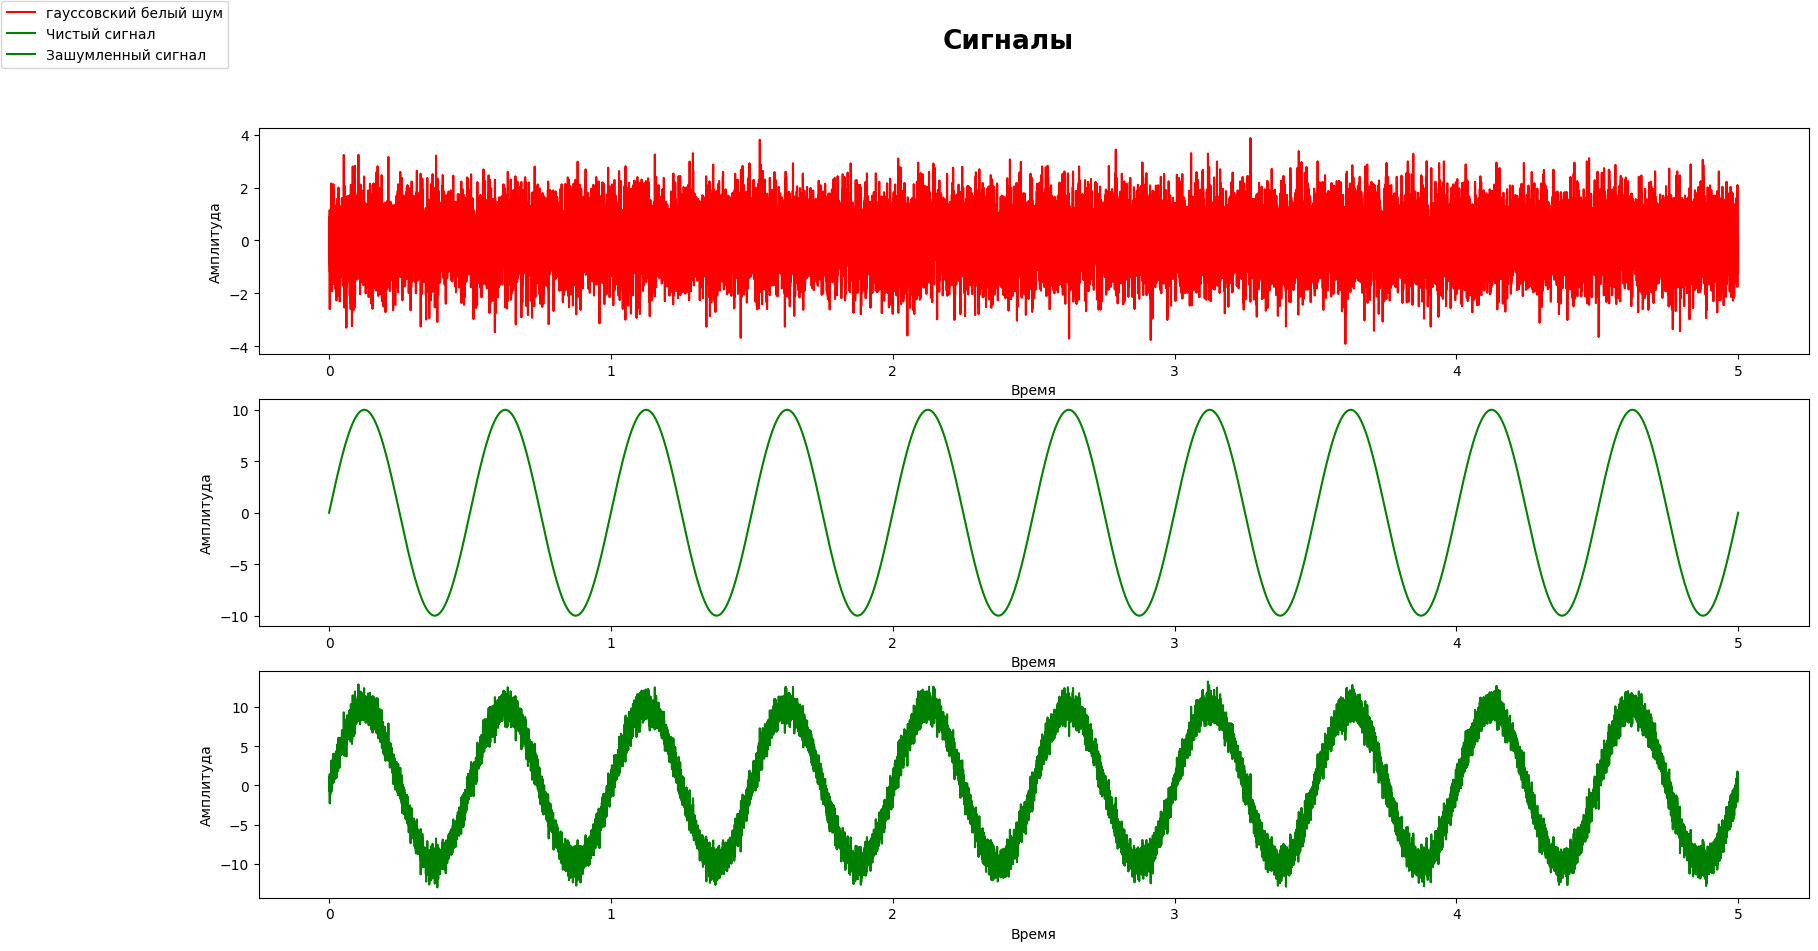

In [ ]:
# Отрисовываем
# хотим нарисовать все на одном рисунке. Нам нужно 3 рисунка, один под другим.
fig, axs = plt.subplots(3, 1, figsize=(20, 10))


# общий заголовок для всей картинки
fig.suptitle('Сигналы', fontsize=19, fontweight='bold')

labels = ["гауссовский белый шум", "Чистый сигнал", "Зашумленный сигнал"]

# определяем, что будем отрисовывать на 1 графике. По x - время, по y - амплитуды
c0 = axs[0].plot(time_points, white_noise_base, color="red")
axs[0].set_xlabel('Время')
axs[0].set_ylabel('Амплитуда')

# определяем, что будем отрисовывать. По x - время, по y - амплитуды
c1 = axs[1].plot(time_points, values, color="green")
axs[1].set_xlabel('Время')
axs[1].set_ylabel('Амплитуда')

# определяем, что будем отрисовывать. По x - время, по y - амплитуды
c2 = axs[2].plot(time_points, values_noise, color="green")
axs[2].set_xlabel('Время')
axs[2].set_ylabel('Амплитуда')

# отрисовываем общую легенду
fig.legend([c0, c1, c2],
           labels=labels,
           loc='upper left',
           borderaxespad=0.1)

